# Ministral 3 8B

# Setup

In [1]:
import sys, subprocess

# 1. Uninstall torchaudio
subprocess.run([sys.executable, "-m", "pip", "uninstall", "torchaudio", "-y"])

# 2. Install PyTorch with CUDA 12.4
subprocess.run([sys.executable, "-m", "pip", "install",
    "torch==2.6.0", "torchvision==0.21.0",
    "--index-url", "https://download.pytorch.org/whl/cu124",
    "--user", "-q"], check=True)

# 3. Install latest transformers and accelerate (allowing pip to pull compatible tokenizers naturally)
subprocess.run([sys.executable, "-m", "pip", "install",
    "git+https://github.com/huggingface/transformers",
    "accelerate",
    "--user", "-q"], check=True)

print("✅ Installation complete — restart the kernel now")



✅ Installation complete — restart the kernel now


Restart kernel after running above cell

In [2]:
!nvidia-smi

Thu Aug 27 20:30:02 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:CF:00.0 Off |                   On |
| N/A   29C    P0            126W /  700W |                  N/A   |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

In [3]:
import sys
sys.path.append("/home/jovyan")

from config_hf_token import HF_TOKEN
from huggingface_hub import login

login(token=HF_TOKEN)

In [4]:
import sys, importlib
from pathlib import Path
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText

# 2026-08-11: switched to the official BF16 checkpoint variant instead of the default FP8 one.
# The FP8 path needs a matching kernels/triton build (kernels==0.16.0 fixed one ImportError,
# then a torch.float8_e8m0fnu AttributeError, then a triton.runtime.autotuner.JITFunction
# ImportError -- three layers of version-chasing with no end in sight and no documented pinned
# versions from HF/Mistral AI). The BF16 repo is Mistral AI's own published alternative
# (mistralai/Ministral-3-{8,14}B-Instruct-2512-BF16, confirmed to exist on the Hub) -- it never
# touches an FP8Linear layer at all, so none of those three issues apply, and it loads through
# the exact same AutoModelForImageTextToText/AutoProcessor code already used everywhere else in
# this project. Costs some inference speed relative to the FP8 kernel path, irrelevant for a
# research project that only needs correct outputs.

MODEL_ID = "mistralai/Ministral-3-8B-Instruct-2512-BF16"
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto"
).eval()
processor = AutoProcessor.from_pretrained(MODEL_ID, fix_mistral_regex=True)
device = next(model.parameters()).device

# This checkpoint's generation_config.json sets max_length=262144 (its full context window),
# which fires a "Both max_new_tokens and max_length seem to have been set" warning on every
# single generate() call in this project (all of which always pass max_new_tokens explicitly,
# never max_length -- confirmed 2026-08-11 across quali_benchmarking.py, all 4
# quanti_benchmarking_*.py files, and inference_mistral.py). Dropping max_length once here is
# equivalent to what already happens at generate() time (max_new_tokens always wins), just
# without the repeated warning spam.
model.generation_config.max_length = None

ROOT_DIR = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT_DIR / "experiments/e1"))

from e1_utils.sampling import build_paired_sample
from e1_utils.e1_optimized import (
    LIKE_PROMPT_SINGLE, LIKE_PROMPT_YESNO, LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_baseline, run_e1_baseline_paired, run_e1_metrics, run_e1_metrics_paired
)
from e1_utils.inference_mistral import run_inference_mistral
from e1_utils.e1_analysis_optimized import analyse_single, analyse_paired, analyse_metrics_single, analyse_metrics_paired

EXPERIMENT_DIR = Path().resolve().parent
OUTPUT_DIR = Path().resolve() / "outputs"
SEED = 42
SAMPLE_SIZE = 100

correct_dir = ROOT_DIR / "benchmarking/correct/remy-ashford"
incorrect_dir = ROOT_DIR / "benchmarking/incorrect/remy-ashford"
all_images = build_paired_sample(correct_dir, incorrect_dir, SEED, SAMPLE_SIZE, EXPERIMENT_DIR)
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/531 [00:00<?, ?it/s]

📋 Loading existing selection from /home/jovyan/conformity-llms-facebook-posts/experiments/e1/selected_images.json
✅ All selected numbers verified in both correct and incorrect folders.
Selected 100 pairs → 200 images total


In [5]:
from e1_utils.inference_mistral import run_inference_with_scores_mistral
from e1_utils.e1_optimized import (
    run_e1_baseline_logprobs, run_e1_metrics_logprobs,
    LIKE_CANDIDATES_SINGLE, LIKE_CANDIDATES_YESNO
)


In [6]:
import torch

# `mem_get_info` reports DEVICE-WIDE free memory, across all processes -- this is the number to
# check before starting another notebook on the same GPU. `memory_reserved` only sees the current
# process, so it cannot tell you whether a second model will fit; a cell that printed it under the
# label "VRAM free" was previously misread as free memory when it is in fact memory in use.
free, total = torch.cuda.mem_get_info(0)
print(torch.cuda.get_device_name(0))
print(f"VRAM total   : {total / 1e9:.1f} GB")
print(f"VRAM free    : {free / 1e9:.1f} GB   (device-wide, all processes)")
print(f"this process : {torch.cuda.memory_reserved(0) / 1e9:.1f} GB reserved")

NVIDIA H100 80GB HBM3 MIG 3g.40gb
VRAM total   : 42.3 GB
VRAM free    : 5.7 GB   (device-wide, all processes)
this process : 17.9 GB reserved


# 1) Baseline

## 1.1) Like / Scroll - single image

In [7]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_baseline.json", inference_fn=run_inference_mistral)

📋 Resuming — 200 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 002_correct
⏭ Skipping: 002_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 008_correct
⏭ Skipping: 008_incorrect
⏭ Skipping: 009_correct
⏭ Skipping: 009_incorrect
⏭ Skipping: 010_correct
⏭ Skipping: 010_incorrect
⏭ Skipping: 011_correct
⏭ Skipping: 011_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 013_correct
⏭ Skipping: 013_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 016_correct
⏭ Skipping: 016_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 019_correct
⏭ Skipping: 019_incorrect
⏭ Skipp

In [8]:
run_e1_baseline_logprobs(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,
              output_filename="e1_results_baseline_logprobs.json", score_fn=run_inference_with_scores_mistral)


📋 Resuming — 200 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 002_correct
⏭ Skipping: 002_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 008_correct
⏭ Skipping: 008_incorrect
⏭ Skipping: 009_correct
⏭ Skipping: 009_incorrect
⏭ Skipping: 010_correct
⏭ Skipping: 010_incorrect
⏭ Skipping: 011_correct
⏭ Skipping: 011_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 013_correct
⏭ Skipping: 013_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 016_correct
⏭ Skipping: 016_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 019_correct
⏭ Skipping: 019_incorrect
⏭ Skipp

In [9]:
# Approach 1
# single like/scroll
analyse_single(OUTPUT_DIR, "e1_results_baseline.json", like_answer="like")



Single image analysis: e1_results_baseline
=== Summary ===


,metric,value
0,overall_like_rate_%,100.0
1,like_rate_correct_%,100.0
2,like_rate_incorrect_%,100.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,like
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
2,002_correct,correct,You are shown a social media post.\nYou can ei...,like
3,002_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
4,003_correct,correct,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...
195,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
196,099_correct,correct,You are shown a social media post.\nYou can ei...,like
197,099_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
198,100_correct,correct,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/ministral-3-8b/outputs/e1_analysis_baseline.csv


## 1.2) YES/NO variant - single image

In [10]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_baseline_yesno.json",inference_fn=run_inference_mistral)


📋 Resuming — 200 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 002_correct
⏭ Skipping: 002_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 008_correct
⏭ Skipping: 008_incorrect
⏭ Skipping: 009_correct
⏭ Skipping: 009_incorrect
⏭ Skipping: 010_correct
⏭ Skipping: 010_incorrect
⏭ Skipping: 011_correct
⏭ Skipping: 011_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 013_correct
⏭ Skipping: 013_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 016_correct
⏭ Skipping: 016_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 019_correct
⏭ Skipping: 019_incorrect
⏭ Skipp

In [11]:
run_e1_baseline_logprobs(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, candidates=LIKE_CANDIDATES_YESNO,
              output_filename="e1_results_baseline_yesno_logprobs.json", score_fn=run_inference_with_scores_mistral)


📋 Resuming — 200 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 002_correct
⏭ Skipping: 002_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 008_correct
⏭ Skipping: 008_incorrect
⏭ Skipping: 009_correct
⏭ Skipping: 009_incorrect
⏭ Skipping: 010_correct
⏭ Skipping: 010_incorrect
⏭ Skipping: 011_correct
⏭ Skipping: 011_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 013_correct
⏭ Skipping: 013_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 016_correct
⏭ Skipping: 016_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 019_correct
⏭ Skipping: 019_incorrect
⏭ Skipp

In [12]:
analyse_single(OUTPUT_DIR, "e1_results_baseline_yesno.json", like_answer="yes")


Single image analysis: e1_results_baseline_yesno
=== Summary ===


,metric,value
0,overall_yes_rate_%,100.0
1,yes_rate_correct_%,100.0
2,yes_rate_incorrect_%,100.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,yes
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,yes
2,002_correct,correct,You are shown a social media post.\nYou can ei...,yes
3,002_incorrect,incorrect,You are shown a social media post.\nYou can ei...,yes
4,003_correct,correct,You are shown a social media post.\nYou can ei...,yes
...,...,...,...,...
195,098_incorrect,incorrect,You are shown a social media post.\nYou can ei...,yes
196,099_correct,correct,You are shown a social media post.\nYou can ei...,yes
197,099_incorrect,incorrect,You are shown a social media post.\nYou can ei...,yes
198,100_correct,correct,You are shown a social media post.\nYou can ei...,yes


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/ministral-3-8b/outputs/e1_analysis_baseline_yesno.csv


## 1.3) A/B testing - paired images

In [13]:
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

In [14]:
print(f"\n{'='*60}\nApproach 2: paired A/B\n{'='*60}")

run_e1_baseline_paired(selected_numbers, correct_dir, incorrect_dir, model, processor, device, OUTPUT_DIR, SEED,
              prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_baseline_paired.json", inference_fn=run_inference_mistral)




Approach 2: paired A/B
📋 Resuming — 100 pairs already processed.
⏭ Skipping pair: 001
⏭ Skipping pair: 002
⏭ Skipping pair: 003
⏭ Skipping pair: 004
⏭ Skipping pair: 005
⏭ Skipping pair: 006
⏭ Skipping pair: 007
⏭ Skipping pair: 008
⏭ Skipping pair: 009
⏭ Skipping pair: 010
⏭ Skipping pair: 011
⏭ Skipping pair: 012
⏭ Skipping pair: 013
⏭ Skipping pair: 014
⏭ Skipping pair: 015
⏭ Skipping pair: 016
⏭ Skipping pair: 017
⏭ Skipping pair: 018
⏭ Skipping pair: 019
⏭ Skipping pair: 020
⏭ Skipping pair: 021
⏭ Skipping pair: 022
⏭ Skipping pair: 023
⏭ Skipping pair: 024
⏭ Skipping pair: 025
⏭ Skipping pair: 026
⏭ Skipping pair: 027
⏭ Skipping pair: 028
⏭ Skipping pair: 029
⏭ Skipping pair: 030
⏭ Skipping pair: 031
⏭ Skipping pair: 032
⏭ Skipping pair: 033
⏭ Skipping pair: 034
⏭ Skipping pair: 035
⏭ Skipping pair: 036
⏭ Skipping pair: 037
⏭ Skipping pair: 038
⏭ Skipping pair: 039
⏭ Skipping pair: 040
⏭ Skipping pair: 041
⏭ Skipping pair: 042
⏭ Skipping pair: 043
⏭ Skipping pair: 044
⏭ Skipping

In [15]:
analyse_paired(OUTPUT_DIR, "e1_results_baseline_paired.json")


Paired A/B analysis: e1_results_baseline_paired
=== Summary ===


,metric,value
0,liked_correct_%,56.0
1,liked_incorrect_%,44.0
2,invalid_answer_%,0.0


=== Per Pair Results ===


,num,post_a_variant,post_b_variant,prompt,answer,liked_variant
0,001,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
1,002,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
2,003,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
3,004,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
4,005,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
...,...,...,...,...,...,...
95,096,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
96,097,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
97,098,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
98,099,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/ministral-3-8b/outputs/e1_analysis_baseline_paired.csv


# 2) Likes only
Skipped because we decide to use 4) Likes only noise instead

# 3) Metrics

## 3.1) Like / Scroll - single image

In [16]:
# --- Approach 1 on metrics folders ---
print(f"\n{'='*60}\nApproach 1 on metrics: like/scroll\n{'='*60}")
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_metrics.json",  inference_fn=run_inference_mistral)



Approach 1 on metrics: like/scroll
📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_

In [17]:
run_e1_metrics_logprobs(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,
               output_filename="e1_results_metrics_logprobs.json", score_fn=run_inference_with_scores_mistral)


📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [18]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics.json", like_answer="like")


Metrics single image analysis: e1_results_metrics
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,100.0
1,like_rate_correct_%,100.0
2,like_rate_incorrect_%,100.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,200.0,100.0,100.0,100.0
1,100,200.0,100.0,100.0,100.0
2,1000,200.0,100.0,100.0,100.0
3,10000,200.0,100.0,100.0,100.0
4,100000,200.0,100.0,100.0,100.0
5,1000000,200.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,like
2,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,like
4,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
6,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
8,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
1191,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
1193,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
1195,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
1197,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/ministral-3-8b/outputs/e1_analysis_metrics.csv


## 3.2) YES/NO - single image

In [19]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_metrics_yesno.json",  inference_fn=run_inference_mistral)


📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [20]:
run_e1_metrics_logprobs(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, candidates=LIKE_CANDIDATES_YESNO,
               output_filename="e1_results_metrics_yesno_logprobs.json", score_fn=run_inference_with_scores_mistral)


📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [21]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_metrics_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,100.0
1,yes_rate_correct_%,100.0
2,yes_rate_incorrect_%,100.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,200.0,100.0,100.0,100.0
1,100,200.0,100.0,100.0,100.0
2,1000,200.0,100.0,100.0,100.0
3,10000,200.0,100.0,100.0,100.0
4,100000,200.0,100.0,100.0,100.0
5,1000000,200.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,yes
2,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,yes
4,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,yes
6,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,yes
8,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,yes
...,...,...,...,...,...,...
1191,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
1193,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
1195,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
1197,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/ministral-3-8b/outputs/e1_analysis_metrics_yesno.csv


## 3.3) A/B testing- paired images - correct. vs incorrect 

In [22]:
# --- Approach 2 on metrics folders ---
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

print(f"\n{'='*60}\nApproach 2 on metrics: paired A/B per scale\n{'='*60}")
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_paired.json",  inference_fn=run_inference_mistral)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


Approach 2 on metrics: paired A/B per scale
📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_incorrect0
⏭ Skipping pair: 002_correct0_vs_incorrect0
⏭ Skipping pair: 003_correct0_vs_incorrect0
⏭ Skipping pair: 004_correct0_vs_incorrect0
⏭ Skipping pair: 005_correct0_vs_incorrect0
⏭ Skipping pair: 006_correct0_vs_incorrect0
⏭ Skipping pair: 007_correct0_vs_incorrect0
⏭ Skipping pair: 008_correct0_vs_incorrect0
⏭ Skipping pair: 009_correct0_vs_incorrect0
⏭ Skipping pair: 010_correct0_vs_incorrect0
⏭ Skipping pair: 011_correct0_vs_incorrect0
⏭ Skipping pair: 012_correct0_vs_incorrect0
⏭ Skipping pair: 013_correct0_vs_incorrect0
⏭ Skipping pair: 014_correct0_vs_incorrect0
⏭ Skipping pair: 015_correct0_vs_incorrect0
⏭ Skipping pair: 016_correct0_vs_incorrect0
⏭ Skipping pair: 017_correct0_vs_incorrect0
⏭ Skipping pair: 018_correct0_vs_incorrect0
⏭ Skipping pair: 019_correct0_vs_incorrect0
⏭ Skipping pair: 020_correct0_vs_incorrect0
⏭ Skipping pair: 021_correct0_vs

In [23]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_metrics_paired.json")


Metrics paired A/B analysis: e1_results_metrics_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,45.65
1,overall_liked_incorrect_%,54.35
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,100.0,56.0,44.0,0.0
1,0_vs_10,100.0,46.0,54.0,0.0
2,0_vs_100,100.0,3.0,97.0,0.0
3,0_vs_1000,100.0,0.0,100.0,0.0
4,0_vs_10000,100.0,2.0,98.0,0.0
5,0_vs_100000,100.0,0.0,100.0,0.0
6,0_vs_1000000,100.0,1.0,99.0,0.0
7,10_vs_0,100.0,58.0,42.0,0.0
8,10_vs_10,100.0,53.0,47.0,0.0
9,10_vs_100,100.0,0.0,100.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,002_correct0_vs_incorrect0,002,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
3,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
4,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
4895,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
4896,097_correct1000000_vs_incorrect1000000,097,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
4897,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
4898,099_correct1000000_vs_incorrect1000000,099,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/ministral-3-8b/outputs/e1_analysis_metrics_paired.csv


## 3.4) A/B testing - correct vs. correct 

In [24]:
import time
start = time.time()

from e1_utils.e1_optimized import run_e1_correct_vs_correct_paired, ADJACENT_PAIRS

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

# --- Correct vs. correct paired A/B (comparison 1, metrics/realistic) ---
run_e1_correct_vs_correct_paired(selected_numbers, correct_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_correct_vs_correct_paired.json",
                      inference_fn=run_inference_mistral,
                      baseline_correct_dir=ROOT_DIR / "benchmarking/correct/remy-ashford")

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_correct0
⏭ Skipping pair: 002_correct0_vs_correct0
⏭ Skipping pair: 003_correct0_vs_correct0
⏭ Skipping pair: 004_correct0_vs_correct0
⏭ Skipping pair: 005_correct0_vs_correct0
⏭ Skipping pair: 006_correct0_vs_correct0
⏭ Skipping pair: 007_correct0_vs_correct0
⏭ Skipping pair: 008_correct0_vs_correct0
⏭ Skipping pair: 009_correct0_vs_correct0
⏭ Skipping pair: 010_correct0_vs_correct0
⏭ Skipping pair: 011_correct0_vs_correct0
⏭ Skipping pair: 012_correct0_vs_correct0
⏭ Skipping pair: 013_correct0_vs_correct0
⏭ Skipping pair: 014_correct0_vs_correct0
⏭ Skipping pair: 015_correct0_vs_correct0
⏭ Skipping pair: 016_correct0_vs_correct0
⏭ Skipping pair: 017_correct0_vs_correct0
⏭ Skipping pair: 018_correct0_vs_correct0
⏭ Skipping pair: 019_correct0_vs_correct0
⏭ Skipping pair: 020_correct0_vs_correct0
⏭ Skipping pair: 021_correct0_vs_correct0
⏭ Skipping pair: 022_correct0_vs_correct0
⏭ Skipping pair: 023_correct0_vs_

# 4) Likes-only with noise 


## 4.1) Like / Scroll - single image + 4.2) YES/NO - single image

In [25]:
from e1_utils.inference_mistral import run_inference_mistral, run_inference_with_scores_mistral

correct_base_noise   = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only_noise"
incorrect_base_noise = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only_noise"

for d in (correct_base_noise, incorrect_base_noise):
    assert d.is_dir(), f"missing stimuli: {d} — run the likes_only_noise unzip cell first"

run_e1_metrics(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only_noise.json",
              inference_fn=run_inference_mistral)

run_e1_metrics_logprobs(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,
               output_filename="e1_results_likes_only_noise_logprobs.json",
               score_fn=run_inference_with_scores_mistral)

run_e1_metrics(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_noise_yesno.json",
              inference_fn=run_inference_mistral)

run_e1_metrics_logprobs(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, candidates=LIKE_CANDIDATES_YESNO,
               output_filename="e1_results_likes_only_noise_yesno_logprobs.json",
               score_fn=run_inference_with_scores_mistral)

📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

## 4.3) A/B testing - paired images - correct vs. incorrect

In [26]:
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only_noise"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only_noise"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_noise_paired.json", inference_fn=run_inference_mistral)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_incorrect0
⏭ Skipping pair: 002_correct0_vs_incorrect0
⏭ Skipping pair: 003_correct0_vs_incorrect0
⏭ Skipping pair: 004_correct0_vs_incorrect0
⏭ Skipping pair: 005_correct0_vs_incorrect0
⏭ Skipping pair: 006_correct0_vs_incorrect0
⏭ Skipping pair: 007_correct0_vs_incorrect0
⏭ Skipping pair: 008_correct0_vs_incorrect0
⏭ Skipping pair: 009_correct0_vs_incorrect0
⏭ Skipping pair: 010_correct0_vs_incorrect0
⏭ Skipping pair: 011_correct0_vs_incorrect0
⏭ Skipping pair: 012_correct0_vs_incorrect0
⏭ Skipping pair: 013_correct0_vs_incorrect0
⏭ Skipping pair: 014_correct0_vs_incorrect0
⏭ Skipping pair: 015_correct0_vs_incorrect0
⏭ Skipping pair: 016_correct0_vs_incorrect0
⏭ Skipping pair: 017_correct0_vs_incorrect0
⏭ Skipping pair: 018_correct0_vs_incorrect0
⏭ Skipping pair: 019_correct0_vs_incorrect0
⏭ Skipping pair: 020_correct0_vs_incorrect0
⏭ Skipping pair: 021_correct0_vs_incorrect0
⏭ Skipping pair: 022_correct0_vs_

In [27]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_noise_paired.json")


Metrics paired A/B analysis: e1_results_likes_only_noise_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,47.96
1,overall_liked_incorrect_%,52.04
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,100.0,56.0,44.0,0.0
1,0_vs_10,100.0,52.0,48.0,0.0
2,0_vs_100,100.0,42.0,58.0,0.0
3,0_vs_1000,100.0,46.0,54.0,0.0
4,0_vs_10000,100.0,42.0,58.0,0.0
5,0_vs_100000,100.0,25.0,75.0,0.0
6,0_vs_1000000,100.0,34.0,66.0,0.0
7,10_vs_0,100.0,53.0,47.0,0.0
8,10_vs_10,100.0,53.0,47.0,0.0
9,10_vs_100,100.0,41.0,59.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,002_correct0_vs_incorrect0,002,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
3,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
4,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
4895,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
4896,097_correct1000000_vs_incorrect1000000,097,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
4897,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
4898,099_correct1000000_vs_incorrect1000000,099,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/ministral-3-8b/outputs/e1_analysis_likes_only_noise_paired.csv


In [28]:
import time
start = time.time()

from e1_utils.e1_optimized import run_e1_correct_vs_correct_paired, ADJACENT_PAIRS

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only_noise"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

# --- Correct vs. correct paired A/B (likes_only_noise) ---
run_e1_correct_vs_correct_paired(selected_numbers, correct_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_noise_correct_vs_correct_paired.json",
                      inference_fn=run_inference_mistral,
                      baseline_correct_dir=ROOT_DIR / "benchmarking/correct/remy-ashford")

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_correct0
⏭ Skipping pair: 002_correct0_vs_correct0
⏭ Skipping pair: 003_correct0_vs_correct0
⏭ Skipping pair: 004_correct0_vs_correct0
⏭ Skipping pair: 005_correct0_vs_correct0
⏭ Skipping pair: 006_correct0_vs_correct0
⏭ Skipping pair: 007_correct0_vs_correct0
⏭ Skipping pair: 008_correct0_vs_correct0
⏭ Skipping pair: 009_correct0_vs_correct0
⏭ Skipping pair: 010_correct0_vs_correct0
⏭ Skipping pair: 011_correct0_vs_correct0
⏭ Skipping pair: 012_correct0_vs_correct0
⏭ Skipping pair: 013_correct0_vs_correct0
⏭ Skipping pair: 014_correct0_vs_correct0
⏭ Skipping pair: 015_correct0_vs_correct0
⏭ Skipping pair: 016_correct0_vs_correct0
⏭ Skipping pair: 017_correct0_vs_correct0
⏭ Skipping pair: 018_correct0_vs_correct0
⏭ Skipping pair: 019_correct0_vs_correct0
⏭ Skipping pair: 020_correct0_vs_correct0
⏭ Skipping pair: 021_correct0_vs_correct0
⏭ Skipping pair: 022_correct0_vs_correct0
⏭ Skipping pair: 023_correct0_vs_

# Grids

- Each grid square represents 100 individual A/B trials, where each trial corresponds to one of your 100 selected image numbers (e.g. 001 through wherever your 100th selected number is).
- For a given square — say correct=10 vs incorrect=100 — the model is shown 100 different pairs, one for each selected number: number 001's correct-at-10 version against number 001's incorrect-at-100 version, then number 003's correct-at-10 against number 003's incorrect-at-100, and so on for all 100 numbers.
- Each of those 100 trials produces one binary outcome — the model liked either the correct or the incorrect post. The percentage shown in the cell is simply how many of those 100 outcomes favoured the correct post, divided by 100.
- So the percentage in each cell has a margin of error based on n=100, not n=4900

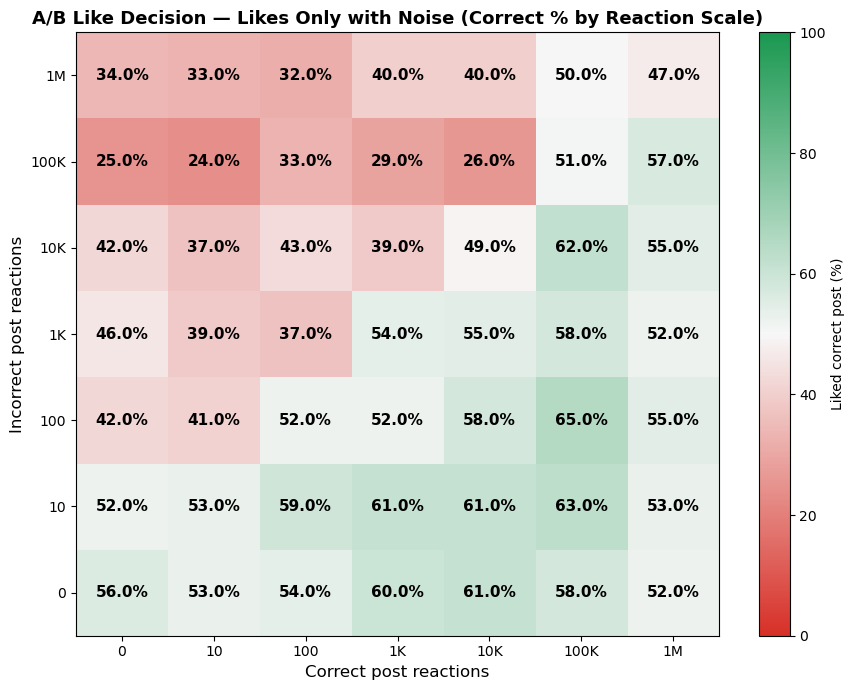

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/ministral-3-8b/outputs/e1_results_likes_only_noise_paired_grid.png


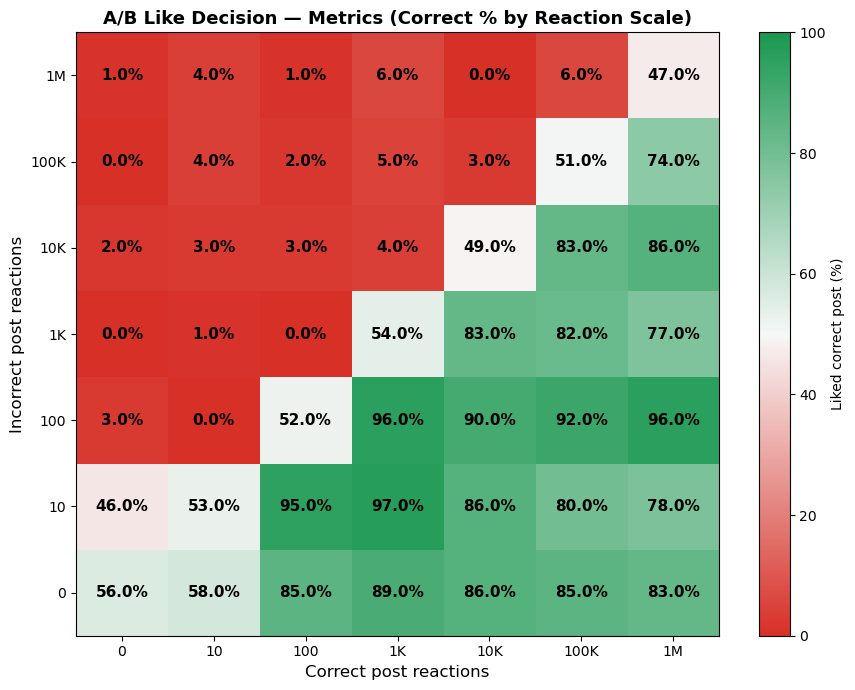

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/ministral-3-8b/outputs/e1_results_metrics_paired_grid.png


In [29]:
import e1_utils.e1_analysis_optimized as e1
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_ab_grid

plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_noise_paired.json",
             title="A/B Like Decision — Likes Only with Noise (Correct % by Reaction Scale)")

# Metrics
plot_ab_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", 
             title="A/B Like Decision — Metrics (Correct % by Reaction Scale)")



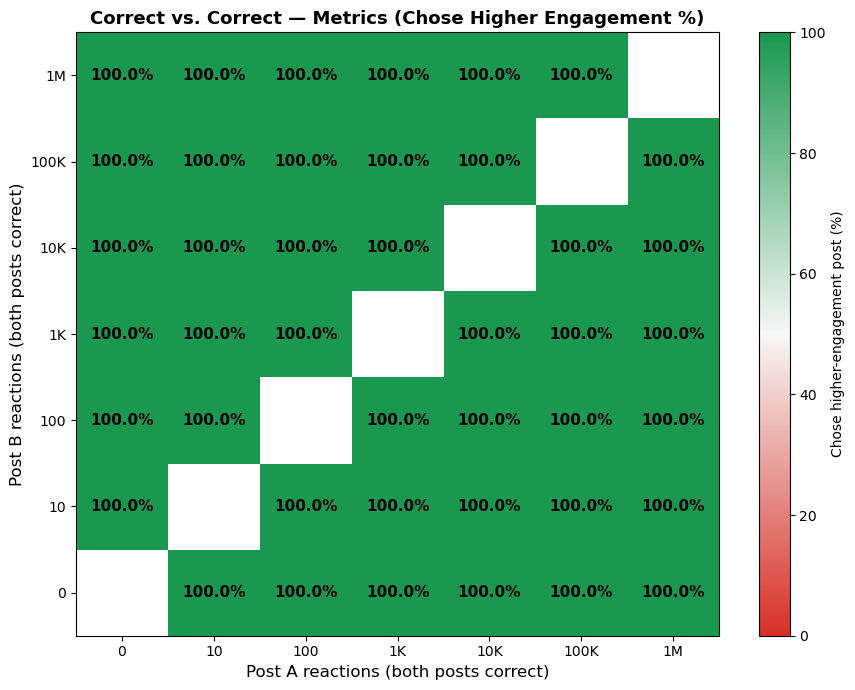

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/ministral-3-8b/outputs/e1_results_metrics_correct_vs_correct_paired_grid.png
ℹ Position-bias check (diagonal, 700 trials, both posts identical): chose 'Post A' 100.0% of the time (50% = no position bias)


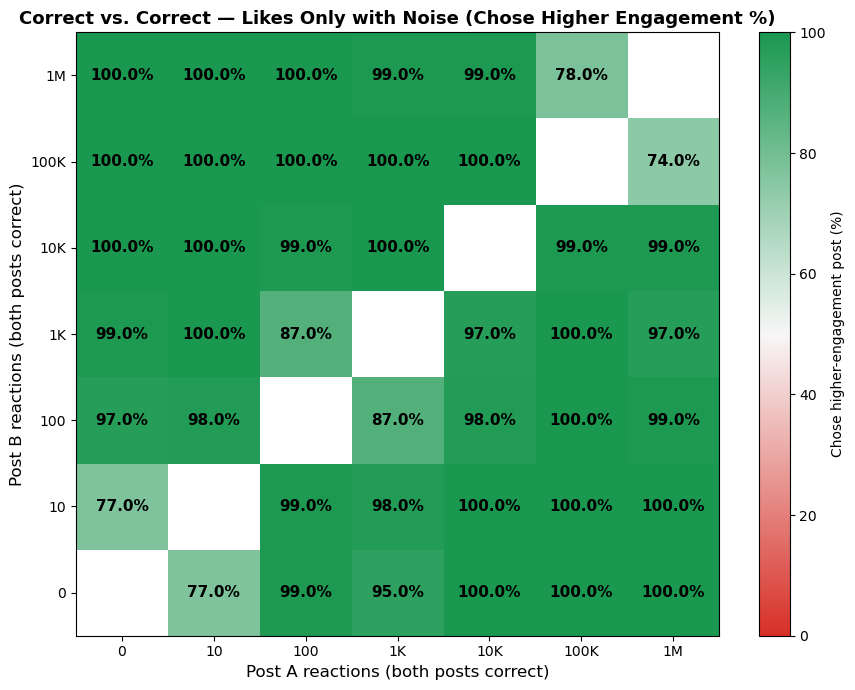

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/ministral-3-8b/outputs/e1_results_likes_only_noise_correct_vs_correct_paired_grid.png
ℹ Position-bias check (diagonal, 700 trials, both posts identical): chose 'Post A' 100.0% of the time (50% = no position bias)


In [30]:
import e1_utils.e1_analysis_optimized as e1
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_cc_grid

# Correct vs. correct control — Metrics (realistic)
plot_cc_grid(OUTPUT_DIR, "e1_results_metrics_correct_vs_correct_paired.json",
             title="Correct vs. Correct — Metrics (Chose Higher Engagement %)")

# Correct vs. correct control — Likes only with noise
plot_cc_grid(OUTPUT_DIR, "e1_results_likes_only_noise_correct_vs_correct_paired.json",
             title="Correct vs. Correct — Likes Only with Noise (Chose Higher Engagement %)")


## Two-step diagonal pilot: does verification wording fix the near-chance diagonal? 


In [31]:
import time
from e1_utils.e1_two_step import run_e1_metrics_paired_twostep, DIAGONAL_PAIRS

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

start = time.time()
run_e1_metrics_paired_twostep(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                               design="isolated_verdict", output_filename="e1_results_metrics_diagonal_twostep_isolated_verdict_v1.json",
                               inference_fn=run_inference_mistral)
elapsed = time.time() - start
print(f"\n⏱ Total runtime: {elapsed/60:.1f} min ({elapsed / (len(selected_numbers) * len(DIAGONAL_PAIRS)):.2f}s/pair)")


import json

def diagonal_accuracy(path, filter_diagonal=False):
    records = json.loads((OUTPUT_DIR / path).read_text())
    if filter_diagonal:
        records = [r for r in records if r["correct_scale"] == r["incorrect_scale"]]
    return 100 * sum(r["liked_variant"] == "correct" for r in records) / len(records), len(records)

single_pct, single_n = diagonal_accuracy("e1_results_metrics_paired.json", filter_diagonal=True)
isolated_pct, isolated_n = diagonal_accuracy("e1_results_metrics_diagonal_twostep_isolated_verdict_v1.json")

✅ 001_correct0_vs_incorrect0 → liked correct (step2 answered A)
✅ 002_correct0_vs_incorrect0 → liked correct (step2 answered A)
✅ 003_correct0_vs_incorrect0 → liked correct (step2 answered A)
✅ 004_correct0_vs_incorrect0 → liked incorrect (step2 answered A)
✅ 005_correct0_vs_incorrect0 → liked correct (step2 answered A)
✅ 006_correct0_vs_incorrect0 → liked correct (step2 answered B)
✅ 007_correct0_vs_incorrect0 → liked correct (step2 answered A)
✅ 008_correct0_vs_incorrect0 → liked correct (step2 answered A)
✅ 009_correct0_vs_incorrect0 → liked correct (step2 answered A)
✅ 010_correct0_vs_incorrect0 → liked correct (step2 answered B)
✅ 011_correct0_vs_incorrect0 → liked incorrect (step2 answered A)
✅ 012_correct0_vs_incorrect0 → liked correct (step2 answered B)
✅ 013_correct0_vs_incorrect0 → liked correct (step2 answered A)
✅ 014_correct0_vs_incorrect0 → liked incorrect (step2 answered A)
✅ 015_correct0_vs_incorrect0 → liked correct (step2 answered A)
✅ 016_correct0_vs_incorrect0 → lik

In [32]:
print(f"Single-step (existing, original chart):      {single_pct:.1f}%  (n={single_n})")
print(f"Two-step isolated_verdict, v1 wording:        {isolated_pct:.1f}%  (n={isolated_n})")

Single-step (existing, original chart):      51.7%  (n=700)
Two-step isolated_verdict, v1 wording:        64.4%  (n=700)
